# Crisiss MMD

## Text Preprocessing

In [1]:
# Import library
import os
import numpy as np
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import spacy
import string
import re

### Load Data

In [2]:
text = pd.read_csv("CrisisMMD_v2.0/annotations/mexico_earthquake_final_data.tsv", 
                  sep = "\t")

In [3]:
text.head()

,tweet_id,image_id,text_info,text_info_conf,image_info,image_info_conf,text_human,text_human_conf,image_human,image_human_conf,image_damage,image_damage_conf,tweet_text,image_url,image_path
0,910523364154003456,910523364154003456_0,not_informative,1.0000,not_informative,1.0000,not_humanitarian,1.0000,not_humanitarian,1.0000,NaN,NaN,RT @FCBarcelona: Our solidarity with the victi...,http://pbs.twimg.com/media/DKLLdbyW0AASG2R.jpg,data_image/mexico_earthquake/20_9_2017/9105233...
1,910523388598280192,910523388598280192_0,informative,1.0000,informative,0.6720,injured_or_dead_people,1.0000,infrastructure_and_utility_damage,0.6720,dont_know_or_cant_judge,0.4174,Mexico earthquake: Many children killed at pri...,http://pbs.twimg.com/media/DKLUMbJV4AACuFU.jpg,data_image/mexico_earthquake/20_9_2017/9105233...
2,910523397448314882,910523397448314882_0,not_informative,0.6643,not_informative,1.0000,not_humanitarian,0.6643,not_humanitarian,1.0000,NaN,NaN,Obamaâ€™s Response To The Earthquake In #Mexic...,http://pbs.twimg.com/media/DKLUND8WAAAHgON.jpg,data_image/mexico_earthquake/20_9_2017/9105233...
3,910523398144397312,910523398144397312_0,informative,0.9282,informative,1.0000,rescue_volunteering_or_donation_effort,0.9282,rescue_volunteering_or_donation_effort,1.0000,NaN,NaN,RT @AmichaiStein1: #BREAKING: Israel search &a...,http://pbs.twimg.com/media/DKK1CuDWsAAX5Vk.jpg,data_image/mexico_earthquake/20_9_2017/9105233...
4,910523398144397312,910523398144397312_1,informative,0.9282,informative,0.6943,rescue_volunteering_or_donation_effort,0.9282,rescue_volunteering_or_donation_effort,0.6943,NaN,NaN,RT @AmichaiStein1: #BREAKING: Israel search &a...,http://pbs.twimg.com/media/DKK1DyDXkAABvBX.jpg,data_image/mexico_earthquake/20_9_2017/9105233...


In [4]:
text.isna().sum()

tweet_id                0
image_id                0
text_info               0
text_info_conf          0
image_info              0
image_info_conf         0
text_human              0
text_human_conf         0
image_human             0
image_human_conf        0
image_damage         1198
image_damage_conf    1198
tweet_text              0
image_url               0
image_path              0
dtype: int64

In [5]:
text['tweet_text'].tolist()

['RT @FCBarcelona: Our solidarity with the victims of the earthquake in Mexico https://t.co/4R52KTn7CB',
 'Mexico earthquake: Many children killed at primary school https://t.co/h0uPkN13mH https://t.co/0vGA5lj758',
 'Obamaâ€™s Response To The Earthquake In #MexicoCity Is What A Real #President #SoundsLike... https://t.co/5EFdMNUgWS https://t.co/ITx4uVwgxf',
 'RT @AmichaiStein1: #BREAKING: Israel search &amp; rescue mission headed to Mexico after 7.1M earthquake https://t.co/lSd0e5ZVdx',
 'RT @AmichaiStein1: #BREAKING: Israel search &amp; rescue mission headed to Mexico after 7.1M earthquake https://t.co/lSd0e5ZVdx',
 'RT @AmichaiStein1: #BREAKING: Israel search &amp; rescue mission headed to Mexico after 7.1M earthquake https://t.co/lSd0e5ZVdx',
 'NEWS: At least 200 people, including 21 children, have died in Mexico after an earthquake hit the country. https://t.co/Wzp6DSKdTs',
 'RT @TravelLeisure: Deadly earthquake shakes Mexico City, causes buildings to crumble https://t.co/Ad7BYyR1b

### Konfig

In [6]:
# Ambil 5 tweet pertama sebagai contoh sebelum preprocessing
sample_indices = [0, 1, 2, 3, 4]
original_samples = [str(text['tweet_text'].iloc[i]) for i in sample_indices]

### Lowercase

In [9]:
# Lowercasing
text["tweet_text"] = text["tweet_text"].apply(lambda x: str(x).lower())

after_step1 = [str(text['tweet_text'].iloc[i]) for i in sample_indices]
for i in range(len(sample_indices)):
    print(f"Sebelum: {original_samples[i]}")
    print(f"Sesudah : {after_step1[i]}")
    print("-" * 60)

Sebelum: RT @FCBarcelona: Our solidarity with the victims of the earthquake in Mexico https://t.co/4R52KTn7CB
Sesudah : rt @fcbarcelona: our solidarity with the victims of the earthquake in mexico https://t.co/4r52ktn7cb
------------------------------------------------------------
Sebelum: Mexico earthquake: Many children killed at primary school https://t.co/h0uPkN13mH https://t.co/0vGA5lj758
Sesudah : mexico earthquake: many children killed at primary school https://t.co/h0upkn13mh https://t.co/0vga5lj758
------------------------------------------------------------
Sebelum: Obamaâ€™s Response To The Earthquake In #MexicoCity Is What A Real #President #SoundsLike... https://t.co/5EFdMNUgWS https://t.co/ITx4uVwgxf
Sesudah : obamaâ€™s response to the earthquake in #mexicocity is what a real #president #soundslike... https://t.co/5efdmnugws https://t.co/itx4uvwgxf
------------------------------------------------------------
Sebelum: RT @AmichaiStein1: #BREAKING: Israel search &amp; rescu

### Hapus URL

In [8]:
text["tweet_text"] = text["tweet_text"].apply(
    lambda x: re.sub(r"http\S+|https\S+|www\.\S+", '', x)
)

after_step2 = [text['tweet_text'].iloc[i] for i in sample_indices]
for i in range(len(sample_indices)):
    print(f"Sebelum: {original_samples[i]}")
    print(f"Sesudah : {after_step2[i]}")
    print("-" * 60)

Sebelum: RT @FCBarcelona: Our solidarity with the victims of the earthquake in Mexico https://t.co/4R52KTn7CB
Sesudah : rt @fcbarcelona: our solidarity with the victims of the earthquake in mexico 
------------------------------------------------------------
Sebelum: Mexico earthquake: Many children killed at primary school https://t.co/h0uPkN13mH https://t.co/0vGA5lj758
Sesudah : mexico earthquake: many children killed at primary school  
------------------------------------------------------------
Sebelum: Obamaâ€™s Response To The Earthquake In #MexicoCity Is What A Real #President #SoundsLike... https://t.co/5EFdMNUgWS https://t.co/ITx4uVwgxf
Sesudah : obamaâ€™s response to the earthquake in #mexicocity is what a real #president #soundslike...  
------------------------------------------------------------
Sebelum: RT @AmichaiStein1: #BREAKING: Israel search &amp; rescue mission headed to Mexico after 7.1M earthquake https://t.co/lSd0e5ZVdx
Sesudah : rt @amichaistein1: #breaking: is

### Tag dan Mention

In [10]:
text["tweet_text"] = text["tweet_text"].apply(
    lambda x: re.sub(r'#|\@\w+', '', x) # hapus mention tapi tidak dengan tags
)

after_step3 = [text['tweet_text'].iloc[i] for i in sample_indices]
for i in range(len(sample_indices)):
    print(f"Sebelum: {original_samples[i]}")
    print(f"Sesudah : {after_step3[i]}")
    print("-" * 60)

Sebelum: RT @FCBarcelona: Our solidarity with the victims of the earthquake in Mexico https://t.co/4R52KTn7CB
Sesudah : rt : our solidarity with the victims of the earthquake in mexico https://t.co/4r52ktn7cb
------------------------------------------------------------
Sebelum: Mexico earthquake: Many children killed at primary school https://t.co/h0uPkN13mH https://t.co/0vGA5lj758
Sesudah : mexico earthquake: many children killed at primary school https://t.co/h0upkn13mh https://t.co/0vga5lj758
------------------------------------------------------------
Sebelum: Obamaâ€™s Response To The Earthquake In #MexicoCity Is What A Real #President #SoundsLike... https://t.co/5EFdMNUgWS https://t.co/ITx4uVwgxf
Sesudah : obamaâ€™s response to the earthquake in mexicocity is what a real president soundslike... https://t.co/5efdmnugws https://t.co/itx4uvwgxf
------------------------------------------------------------
Sebelum: RT @AmichaiStein1: #BREAKING: Israel search &amp; rescue mission heade

### Hapus Emoji

In [11]:
import emoji
text["tweet_text"] = text["tweet_text"].apply(
    lambda x: emoji.replace_emoji(x, replace=' ')
)

after_step4 = [text['tweet_text'].iloc[i] for i in sample_indices]
for i in range(len(sample_indices)):
    print(f"Sebelum: {original_samples[i]}")
    print(f"Sesudah : {after_step4[i]}")
    print("-" * 60)

Sebelum: RT @FCBarcelona: Our solidarity with the victims of the earthquake in Mexico https://t.co/4R52KTn7CB
Sesudah : rt : our solidarity with the victims of the earthquake in mexico https://t.co/4r52ktn7cb
------------------------------------------------------------
Sebelum: Mexico earthquake: Many children killed at primary school https://t.co/h0uPkN13mH https://t.co/0vGA5lj758
Sesudah : mexico earthquake: many children killed at primary school https://t.co/h0upkn13mh https://t.co/0vga5lj758
------------------------------------------------------------
Sebelum: Obamaâ€™s Response To The Earthquake In #MexicoCity Is What A Real #President #SoundsLike... https://t.co/5EFdMNUgWS https://t.co/ITx4uVwgxf
Sesudah : obamaâ€ s response to the earthquake in mexicocity is what a real president soundslike... https://t.co/5efdmnugws https://t.co/itx4uvwgxf
------------------------------------------------------------
Sebelum: RT @AmichaiStein1: #BREAKING: Israel search &amp; rescue mission heade

### Rapihkan Spasi

In [12]:
text["tweet_text"] = text["tweet_text"].apply(
    lambda x: re.sub(r'\s+', ' ', x).strip()
)

after_step5 = [text['tweet_text'].iloc[i] for i in sample_indices]
for i in range(len(sample_indices)):
    print(f"Sebelum: {original_samples[i]}")
    print(f"Sesudah : {after_step5[i]}")
    print("-" * 60)

Sebelum: RT @FCBarcelona: Our solidarity with the victims of the earthquake in Mexico https://t.co/4R52KTn7CB
Sesudah : rt : our solidarity with the victims of the earthquake in mexico https://t.co/4r52ktn7cb
------------------------------------------------------------
Sebelum: Mexico earthquake: Many children killed at primary school https://t.co/h0uPkN13mH https://t.co/0vGA5lj758
Sesudah : mexico earthquake: many children killed at primary school https://t.co/h0upkn13mh https://t.co/0vga5lj758
------------------------------------------------------------
Sebelum: Obamaâ€™s Response To The Earthquake In #MexicoCity Is What A Real #President #SoundsLike... https://t.co/5EFdMNUgWS https://t.co/ITx4uVwgxf
Sesudah : obamaâ€ s response to the earthquake in mexicocity is what a real president soundslike... https://t.co/5efdmnugws https://t.co/itx4uvwgxf
------------------------------------------------------------
Sebelum: RT @AmichaiStein1: #BREAKING: Israel search &amp; rescue mission heade

### Menghapus Angka dan Satuan Angka

In [13]:
def remove_rank_size_and_time(x):
    x = str(x)
    # Hapus pola: 2nd
    x = re.sub(r'\b\d+\s*(st|nd|rd|th)\b', '', x, flags=re.I)
    # hapus pola 10k, 8k
    x = re.sub(r'\b\d+\s*(k|m)\b', '', x, flags = re.I)
    # Hapus pola waktu: 7 pm, 10 am, 7pm, 10am
    x = re.sub(r'\b\d+\s*(am|pm)\b', '', x, flags=re.I)
    # hapus angka
    x = re.sub(r'\d+', '', x, flags = re.I)
    return x

text['tweet_text'] = text['tweet_text'].apply(remove_rank_size_and_time)

after_step6 = [text['tweet_text'].iloc[i] for i in sample_indices]
for i in range(len(sample_indices)):
    print(f"Sebelum: {original_samples[i]}")
    print(f"Sesudah : {after_step6[i]}")
    print("-" * 60)

Sebelum: RT @FCBarcelona: Our solidarity with the victims of the earthquake in Mexico https://t.co/4R52KTn7CB
Sesudah : rt : our solidarity with the victims of the earthquake in mexico https://t.co/rktncb
------------------------------------------------------------
Sebelum: Mexico earthquake: Many children killed at primary school https://t.co/h0uPkN13mH https://t.co/0vGA5lj758
Sesudah : mexico earthquake: many children killed at primary school https://t.co/hupknmh https://t.co/vgalj
------------------------------------------------------------
Sebelum: Obamaâ€™s Response To The Earthquake In #MexicoCity Is What A Real #President #SoundsLike... https://t.co/5EFdMNUgWS https://t.co/ITx4uVwgxf
Sesudah : obamaâ€ s response to the earthquake in mexicocity is what a real president soundslike... https://t.co/efdmnugws https://t.co/itxuvwgxf
------------------------------------------------------------
Sebelum: RT @AmichaiStein1: #BREAKING: Israel search &amp; rescue mission headed to Mexico af

### Hapus Tanda Baca

In [14]:
import string

text['tweet_text'] = text['tweet_text'].apply(
    lambda x: re.sub(r'[^a-zA-Z\s]', '', x)
)

after_step7 = [text['tweet_text'].iloc[i] for i in sample_indices]
for i in range(len(sample_indices)):
    print(f"Sebelum: {original_samples[i]}")
    print(f"Sesudah : {after_step7[i]}")
    print("-" * 60)

Sebelum: RT @FCBarcelona: Our solidarity with the victims of the earthquake in Mexico https://t.co/4R52KTn7CB
Sesudah : rt  our solidarity with the victims of the earthquake in mexico httpstcorktncb
------------------------------------------------------------
Sebelum: Mexico earthquake: Many children killed at primary school https://t.co/h0uPkN13mH https://t.co/0vGA5lj758
Sesudah : mexico earthquake many children killed at primary school httpstcohupknmh httpstcovgalj
------------------------------------------------------------
Sebelum: Obamaâ€™s Response To The Earthquake In #MexicoCity Is What A Real #President #SoundsLike... https://t.co/5EFdMNUgWS https://t.co/ITx4uVwgxf
Sesudah : obama s response to the earthquake in mexicocity is what a real president soundslike httpstcoefdmnugws httpstcoitxuvwgxf
------------------------------------------------------------
Sebelum: RT @AmichaiStein1: #BREAKING: Israel search &amp; rescue mission headed to Mexico after 7.1M earthquake https://t.co

### Hapus RT

In [15]:
text['tweet_text'] = text['tweet_text'].apply(
    lambda x: re.sub(r'\brt\b', '', x)
)

after_step8 = [text['tweet_text'].iloc[i] for i in sample_indices]
for i in range(len(sample_indices)):
    print(f"Sebelum: {original_samples[i]}")
    print(f"Sesudah : {after_step8[i]}")
    print("-" * 60)

Sebelum: RT @FCBarcelona: Our solidarity with the victims of the earthquake in Mexico https://t.co/4R52KTn7CB
Sesudah :   our solidarity with the victims of the earthquake in mexico httpstcorktncb
------------------------------------------------------------
Sebelum: Mexico earthquake: Many children killed at primary school https://t.co/h0uPkN13mH https://t.co/0vGA5lj758
Sesudah : mexico earthquake many children killed at primary school httpstcohupknmh httpstcovgalj
------------------------------------------------------------
Sebelum: Obamaâ€™s Response To The Earthquake In #MexicoCity Is What A Real #President #SoundsLike... https://t.co/5EFdMNUgWS https://t.co/ITx4uVwgxf
Sesudah : obama s response to the earthquake in mexicocity is what a real president soundslike httpstcoefdmnugws httpstcoitxuvwgxf
------------------------------------------------------------
Sebelum: RT @AmichaiStein1: #BREAKING: Israel search &amp; rescue mission headed to Mexico after 7.1M earthquake https://t.co/l

### Stopword

In [16]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

def stopwords_tokens(text):
    tokens = [w for w in word_tokenize(text) if w not in stop_words]
    return ' '.join(tokens)

text['stopwords'] = text['tweet_text'].apply(stopwords_tokens)

after_step9 = [text['tweet_text'].iloc[i] for i in sample_indices]
for i in range(len(sample_indices)):
    print(f"Sebelum: {original_samples[i]}")
    print(f"Sesudah : {after_step9[i]}")
    print("-" * 60)

Sebelum: RT @FCBarcelona: Our solidarity with the victims of the earthquake in Mexico https://t.co/4R52KTn7CB
Sesudah :   our solidarity with the victims of the earthquake in mexico httpstcorktncb
------------------------------------------------------------
Sebelum: Mexico earthquake: Many children killed at primary school https://t.co/h0uPkN13mH https://t.co/0vGA5lj758
Sesudah : mexico earthquake many children killed at primary school httpstcohupknmh httpstcovgalj
------------------------------------------------------------
Sebelum: Obamaâ€™s Response To The Earthquake In #MexicoCity Is What A Real #President #SoundsLike... https://t.co/5EFdMNUgWS https://t.co/ITx4uVwgxf
Sesudah : obama s response to the earthquake in mexicocity is what a real president soundslike httpstcoefdmnugws httpstcoitxuvwgxf
------------------------------------------------------------
Sebelum: RT @AmichaiStein1: #BREAKING: Israel search &amp; rescue mission headed to Mexico after 7.1M earthquake https://t.co/l

### Function

In [ ]:
# def clean_text(text):
    #if not isinstance(text, str):
        #return ''
    #text = text.lower()
    #text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    #text = re.sub(r'@\w+|#', '', text)
    #text = re.sub(r'\b\d+\s*(st|nd|rd|th)\b', '', text, flags=re.I)
    #text = re.sub(r'\b\d+\s*(k|m)\b', '', text, flags=re.I)
    #text = re.sub(r'\b\d+\s*(am|pm)\b', '', text, flags=re.I)
    #text = re.sub(r'\d+', '', text)
    #text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    #text = re.sub(r'\brt\b', '', text)
    #text = re.sub(r'\s+', ' ', text).strip()
    #tokens = [w for w in word_tokenize(text) if w not in stop_words]
    #return ' '.join(tokens)
#text['function'] = text['tweet_text'].apply(clean_text)

In [ ]:
#text[['tweet_text', 'function']]

,tweet_text,function
0,RT @FCBarcelona: Our solidarity with the victi...,solidarity victims earthquake mexico
1,Mexico earthquake: Many children killed at pri...,mexico earthquake many children killed primary...
2,Obamaâ€™s Response To The Earthquake In #Mexic...,obama response earthquake mexicocity real pres...
3,RT @AmichaiStein1: #BREAKING: Israel search &a...,breaking israel search amp rescue mission head...
4,RT @AmichaiStein1: #BREAKING: Israel search &a...,breaking israel search amp rescue mission head...
...,...,...
1375,Carlos santana donates $100k to mexico earthqu...,carlos santana donates mexico earthquake relie...
1376,Seth troxler donates 10k to earthquake relief ...,seth troxler donates earthquake relief efforts...
1377,Entercom/San Francisco Stations Raise Funds Fo...,entercom san francisco stations raise funds me...
1378,Mexico Earthquakes | International Medical Cor...,mexico earthquakes international medical corps


### Lemmatization

In [17]:
wnl = WordNetLemmatizer()
text["tweet_text"] = text["tweet_text"].apply(
    lambda x: " ".join([wnl.lemmatize(word, pos='v') for word in x.split()])
)

after_step10 = [text['tweet_text'].iloc[i] for i in sample_indices]
for i in range(len(sample_indices)):
    print(f"Sebelum: {original_samples[i]}")
    print(f"Sesudah : {after_step10[i]}")
    print("-" * 60)

Sebelum: RT @FCBarcelona: Our solidarity with the victims of the earthquake in Mexico https://t.co/4R52KTn7CB
Sesudah : our solidarity with the victims of the earthquake in mexico httpstcorktncb
------------------------------------------------------------
Sebelum: Mexico earthquake: Many children killed at primary school https://t.co/h0uPkN13mH https://t.co/0vGA5lj758
Sesudah : mexico earthquake many children kill at primary school httpstcohupknmh httpstcovgalj
------------------------------------------------------------
Sebelum: Obamaâ€™s Response To The Earthquake In #MexicoCity Is What A Real #President #SoundsLike... https://t.co/5EFdMNUgWS https://t.co/ITx4uVwgxf
Sesudah : obama s response to the earthquake in mexicocity be what a real president soundslike httpstcoefdmnugws httpstcoitxuvwgxf
------------------------------------------------------------
Sebelum: RT @AmichaiStein1: #BREAKING: Israel search &amp; rescue mission headed to Mexico after 7.1M earthquake https://t.co/lSd0e

## Image Preprocessing

In [19]:
text.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1380 entries, 0 to 1379
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   tweet_id           1380 non-null   int64  
 1   image_id           1380 non-null   object 
 2   text_info          1380 non-null   object 
 3   text_info_conf     1380 non-null   float64
 4   image_info         1380 non-null   object 
 5   image_info_conf    1380 non-null   float64
 6   text_human         1380 non-null   object 
 7   text_human_conf    1380 non-null   float64
 8   image_human        1380 non-null   object 
 9   image_human_conf   1380 non-null   float64
 10  image_damage       182 non-null    object 
 11  image_damage_conf  182 non-null    float64
 12  tweet_text         1380 non-null   object 
 13  image_url          1380 non-null   object 
 14  image_path         1380 non-null   object 
 15  1_lowercasing      1380 non-null   object 
 16  2_no_urls          1380 

In [18]:
# Import Library
import os
import pandas as pd
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm  # Progress bar
import warnings
warnings.filterwarnings('ignore') 

### Konfig

In [19]:
BASE_DIR = "CrisisMMD_v2.0"   # folder utama project
IMG_SIZE = (224, 224)         # (W, H) target image size
TH_INFO = 0.7                 # threshold confidence untuk label image_info

### Load Data

In [20]:
df = text.copy()   # jadikan salinan dataframe text

print("Shape df (dari preprocessing teks):", df.shape)
print("Kolom-kolom yang ada:", df.columns.tolist())

print("\nContoh image_path mentah:")
print(df["image_path"].head())

# Ambil hanya baris yang punya image_path
df_img = df[~df["image_path"].isna()].copy()

# Bangun full_path ke file gambar
def make_full_path(rel_path):
    rel_path = str(rel_path).lstrip("/\\")  # buang leading slash/backslash
    return os.path.normpath(os.path.join(BASE_DIR, rel_path))

df_img["full_path"] = df_img["image_path"].apply(make_full_path)

print("\nContoh full_path:")
print(df_img[["image_id", "image_path", "full_path"]].head())

Shape df (dari preprocessing teks): (1380, 16)
Kolom-kolom yang ada: ['tweet_id', 'image_id', 'text_info', 'text_info_conf', 'image_info', 'image_info_conf', 'text_human', 'text_human_conf', 'image_human', 'image_human_conf', 'image_damage', 'image_damage_conf', 'tweet_text', 'image_url', 'image_path', 'stopwords']

Contoh image_path mentah:
0    data_image/mexico_earthquake/20_9_2017/9105233...
1    data_image/mexico_earthquake/20_9_2017/9105233...
2    data_image/mexico_earthquake/20_9_2017/9105233...
3    data_image/mexico_earthquake/20_9_2017/9105233...
4    data_image/mexico_earthquake/20_9_2017/9105233...
Name: image_path, dtype: object

Contoh full_path:
               image_id                                         image_path  \
0  910523364154003456_0  data_image/mexico_earthquake/20_9_2017/9105233...   
1  910523388598280192_0  data_image/mexico_earthquake/20_9_2017/9105233...   
2  910523397448314882_0  data_image/mexico_earthquake/20_9_2017/9105233...   
3  910523398144397

In [21]:
# Task A: gunakan kolom `image_info` dan `image_info_conf`
#  - buang baris yang tidak punya label
#  - buang label dengan confidence rendah (di bawah TH_INFO)

mask_has_label = ~df_img["image_info"].isna()
mask_conf_ok  = df_img["image_info_conf"] >= TH_INFO

df_taskA = df_img[mask_has_label & mask_conf_ok].copy()
df_taskA.reset_index(drop=True, inplace=True)

print("\nJumlah baris dengan label image_info & conf >= TH_INFO:", df_taskA.shape[0])

print("Distribusi label image_info:")
print(df_taskA["image_info"].value_counts())


Jumlah baris dengan label image_info & conf >= TH_INFO: 848
Distribusi label image_info:
image_info
informative        471
not_informative    377
Name: count, dtype: int64


In [22]:
# CEK KEBERADAAN FILE GAMBAR

df_taskA["exists"] = df_taskA["full_path"].apply(os.path.exists)

missing_files = df_taskA[~df_taskA["exists"]]
print("\nJumlah file gambar yang tidak ditemukan (Task A):", len(missing_files))
if len(missing_files) > 0:
    print("Contoh file yang hilang:")
    print(missing_files[["image_id", "full_path"]].head())

df_taskA = df_taskA[df_taskA["exists"]].copy()
df_taskA.reset_index(drop=True, inplace=True)

print("Jumlah baris Task A yang akan diproses:", df_taskA.shape[0])


Jumlah file gambar yang tidak ditemukan (Task A): 0
Jumlah baris Task A yang akan diproses: 848


### Preprocessing

In [23]:
# Encode label image_info 

# Misal nilai unik: ["informative", "not_informative"]
# Tapi biar umum, kita buat mapping otomatis

unique_labels = sorted(df_taskA["image_info"].unique())
label2id = {lab: i for i, lab in enumerate(unique_labels)}
print("\nMapping label2id (image_info):", label2id)

df_taskA["image_info_id"] = df_taskA["image_info"].map(label2id)
y_info = df_taskA["image_info_id"].values


Mapping label2id (image_info): {'informative': 0, 'not_informative': 1}


In [ ]:
def preprocess_image_cv2(path, img_size=IMG_SIZE, debug=False):
    """
    Preprocessing dasar:
    1. read BGR (cv2)
    2. convert ke RGB
    3. resize ke img_size
    4. scale ke [0,1]

    Jika debug=True, kembalikan juga dict image per tahap.
    """
    debug_imgs = {}

    # 1. LOAD BGR
    img_bgr = cv2.imread(path)
    if img_bgr is None:
        print(f"Gagal load: {path}")
        return None if not debug else (None, None)

    debug_imgs["bgr_raw"] = img_bgr.copy()

    # 2. BGR -> RGB
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    debug_imgs["rgb"] = img_rgb.copy()

    # 3. RESIZE
    img_resized = cv2.resize(img_rgb, img_size, interpolation=cv2.INTER_AREA)
    debug_imgs["resized"] = img_resized.copy()

    # 4. NORMALISASI [0,1]
    img_norm = img_resized.astype(np.float32) / 255.0
    debug_imgs["normalized"] = img_norm.copy()

    if debug:
        return img_norm, debug_imgs
    else:
        return img_norm

In [27]:
# Output image process
def show_debug_steps(debug_imgs, title_prefix=""):
    plt.figure(figsize=(12, 6))

    plt.subplot(2, 2, 1)
    plt.imshow(cv2.cvtColor(debug_imgs["bgr_raw"], cv2.COLOR_BGR2RGB))
    plt.title(f"{title_prefix} - BGR Raw")
    plt.axis("off")

    plt.subplot(2, 2, 2)
    plt.imshow(debug_imgs["rgb"])
    plt.title(f"{title_prefix} - RGB")
    plt.axis("off")

    plt.subplot(2, 2, 3)
    plt.imshow(debug_imgs["resized"])
    plt.title(f"{title_prefix} - Resized {IMG_SIZE}")
    plt.axis("off")

    plt.subplot(2, 2, 4)
    plt.imshow(debug_imgs["normalized"])
    vmin = debug_imgs["normalized"].min()
    vmax = debug_imgs["normalized"].max()
    plt.title(f"{title_prefix} - Normalized\nmin={vmin:.3f}, max={vmax:.3f}")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


=== DEMO PREPROCESSING UNTUK GAMBAR 0 (label: not_informative) ===
Path: CrisisMMD_v2.0\data_image\mexico_earthquake\20_9_2017\910523364154003456_0.jpg
Shape setelah preprocessing: (224, 224, 3)
Range nilai: 0.0 sampai 0.99215686


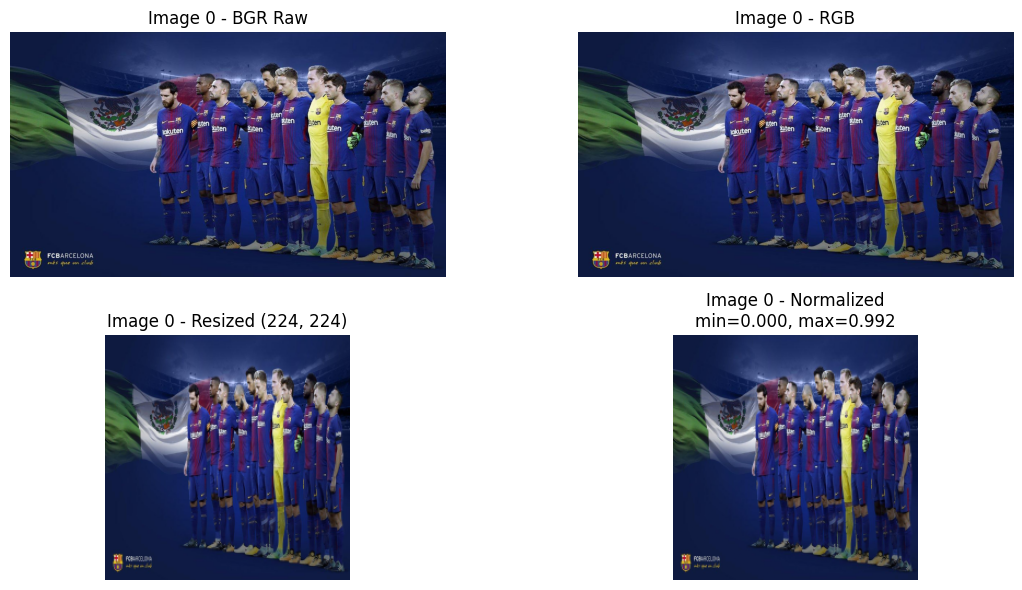


=== DEMO PREPROCESSING UNTUK GAMBAR 1 (label: not_informative) ===
Path: CrisisMMD_v2.0\data_image\mexico_earthquake\20_9_2017\910523397448314882_0.jpg
Shape setelah preprocessing: (224, 224, 3)
Range nilai: 0.0 sampai 1.0


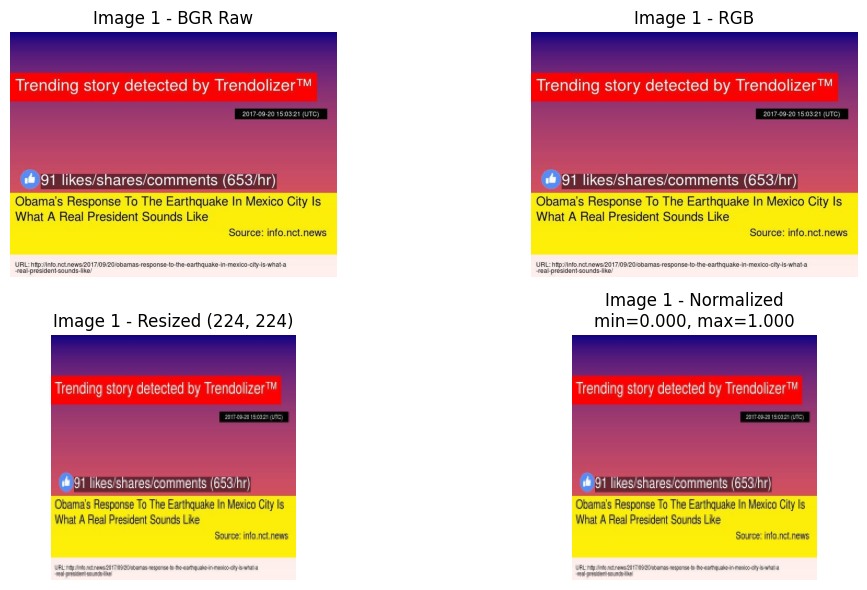


=== DEMO PREPROCESSING UNTUK GAMBAR 2 (label: informative) ===
Path: CrisisMMD_v2.0\data_image\mexico_earthquake\20_9_2017\910523398144397312_0.jpg
Shape setelah preprocessing: (224, 224, 3)
Range nilai: 0.011764706 sampai 1.0


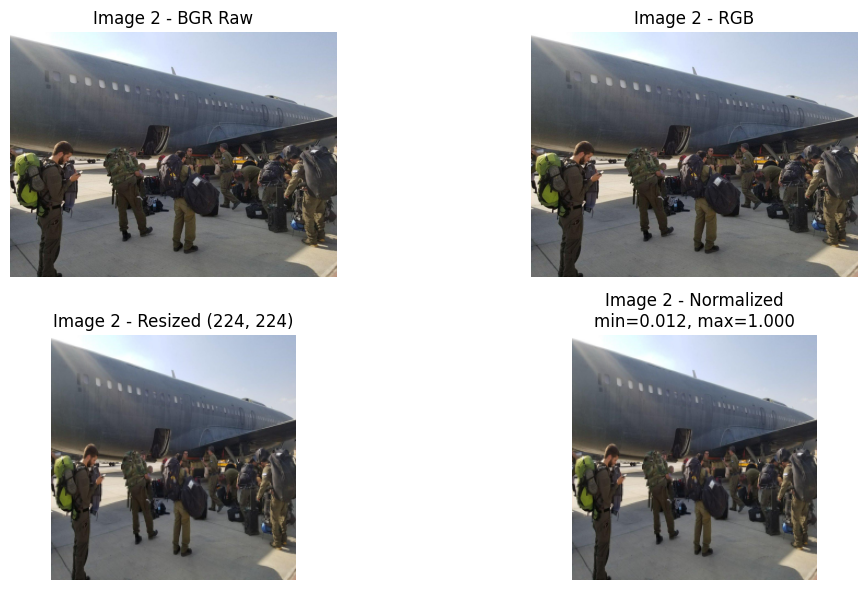

In [28]:
n_demo = min(3, len(df_taskA))
for i in range(n_demo):
    sample_path = df_taskA.loc[i, "full_path"]
    sample_label = df_taskA.loc[i, "image_info"]
    print(f"\n=== DEMO PREPROCESSING UNTUK GAMBAR {i} (label: {sample_label}) ===")
    print("Path:", sample_path)
    img_norm, dbg = preprocess_image_cv2(sample_path, debug=True)
    if img_norm is None:
        continue
    print("Shape setelah preprocessing:", img_norm.shape)
    print("Range nilai:", img_norm.min(), "sampai", img_norm.max())
    show_debug_steps(dbg, title_prefix=f"Image {i}")

In [29]:
# Preprocess semua gambar 

all_images = []
valid_indices = []

for idx, row in tqdm(df_taskA.iterrows(),
                     total=len(df_taskA),
                     desc="Preprocessing image Task A (informativeness)"):
    img_array = preprocess_image_cv2(row["full_path"], debug=False)
    if img_array is not None:
        all_images.append(img_array)
        valid_indices.append(idx)

if len(all_images) == 0:
    raise RuntimeError("Tidak ada gambar yang berhasil diproses untuk Task A.")

X_images = np.stack(all_images, axis=0)
df_taskA_clean = df_taskA.loc[valid_indices].reset_index(drop=True)
y_info = df_taskA_clean["image_info_id"].values  # pastikan sinkron

print("\n=== RINGKASAN AKHIR TASK A ===")
print("Shape array gambar (X_images):", X_images.shape)
print("Pixel range:", X_images.min(), "sampai", X_images.max())
print("Shape label (y_info):", y_info.shape)
print("Contoh mapping label:", label2id)

Preprocessing image Task A (informativeness): 100%|██████████| 848/848 [00:08<00:00, 98.51it/s] 



=== RINGKASAN AKHIR TASK A ===
Shape array gambar (X_images): (848, 224, 224, 3)
Pixel range: 0.0 sampai 1.0
Shape label (y_info): (848,)
Contoh mapping label: {'informative': 0, 'not_informative': 1}
